<a href="https://colab.research.google.com/github/rafaelkrj/Data_Science_and_Analytics_Portfolio/blob/main/Exploring_Airbnb_Prices_in_Madrid_Spain.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# *Airbnb Data Analysis - Madrid/Spain*

<img src="https://upload.wikimedia.org/wikipedia/commons/thumb/6/69/Airbnb_Logo_B%C3%A9lo.svg/960px-Airbnb_Logo_B%C3%A9lo.svg.png" width = 20% />

Across Europe, there has been a significant increase in tourist flow, and recent reports show that hotel prices have reached record levels, and continue to rise with no clear ceiling [1]. In cities such as Madrid, average accommodation prices range from 170 to 174 euros per night, while prices in other destinations vary depending on local supply and tourism demand [2]. Therefore, it is relevant to examine a sample of Airbnb listings to see how current prices compare within the local accommodation market in Madrid. This analysis also allows us to compare accommodation types, identify which ones are priced higher, and examine additional characteristics of the listings.

We use Airbnb data provided by the Inside Airbnb platform [3]. The dataset includes summary information and key metrics for Airbnb listings in Madrid, Comunidad de Madrid. It covers the last 12 months, as described by the data provider. In this study, we conduct an Exploratory Data Analysis (EDA) of this dataset. By the end, we aim to summarize the main descriptive statistics and investigate price differences across accommodation types in Madrid.

The stages of this analysis will be:

1. Understand each variable in the dataset to clean, transform, or split them in order to focus on the variable price.
1. Explore the variable price and look for patterns that provide useful information.
1. Create graphs to analyze the possible association and correlation with other variables.
3. Check the prices of hotel rooms in this sample and compare them with the news reports.

*"Inside Airbnb is a mission driven project that provides data and advocacy about Airbnb's impact on residential communities"* For more details, see https://insideairbnb.com/about/.

# The Dataset


In [ ]:
# Modules used in this analysis
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
# Load the dataset and preview the first 5 rows
path = 'https://data.insideairbnb.com/spain/comunidad-de-madrid/madrid/2025-09-14/visualisations/listings.csv'
df = pd.read_csv(path)
df.head()

,id,name,host_id,host_name,neighbourhood_group,neighbourhood,latitude,longitude,room_type,price,minimum_nights,number_of_reviews,last_review,reviews_per_month,calculated_host_listings_count,availability_365,number_of_reviews_ltm,license
0,21853,Bright and airy room,83531,Abdel,Latina,Cármenes,40.40381,-3.74130,Private room,NaN,4,33,2018-07-15,0.25,2,198,0,NaN
1,30320,Apartamentos Dana Sol,130907,Danuta Weronika,Centro,Sol,40.41476,-3.70418,Entire home/apt,157.0,5,173,2025-08-27,0.93,17,342,1,NaN
2,30959,Beautiful loft in Madrid Center,132883,Angela,Centro,Embajadores,40.41259,-3.70105,Entire home/apt,NaN,3,8,2017-05-30,0.06,1,0,0,NaN
3,40916,Apartasol Apartamentos Dana,130907,Danuta Weronika,Centro,Universidad,40.42247,-3.70577,Entire home/apt,143.0,5,53,2025-09-11,0.29,17,341,4,NaN
4,62423,MAGIC ARTISTIC HOUSE IN THE CENTER OF MADRID,303845,Arturo,Centro,Justicia,40.41884,-3.69655,Private room,65.0,1,249,2025-09-05,2.78,3,299,41,NaN


## Size of the Dataset
The dataset includes 25,000 rows and 18 variables, with a memory usage of approximately 3.4 MB.

In [ ]:
df.shape

(25000, 18)

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 25000 entries, 0 to 24999
Data columns (total 18 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   id                              25000 non-null  int64  
 1   name                            25000 non-null  object 
 2   host_id                         25000 non-null  int64  
 3   host_name                       24903 non-null  object 
 4   neighbourhood_group             25000 non-null  object 
 5   neighbourhood                   25000 non-null  object 
 6   latitude                        25000 non-null  float64
 7   longitude                       25000 non-null  float64
 8   room_type                       25000 non-null  object 
 9   price                           18953 non-null  float64
 10  minimum_nights                  25000 non-null  int64  
 11  number_of_reviews               25000 non-null  int64  
 12  last_review                     

## Data Dictionary
Variable (dtype): Description

1. **id** (int64): Airbnb’s unique identifier for the listing.
2. **name** (object): Name of the listing.
3. **host_id** (int64): Airbnb's unique identifier for the host.
4. **host_name** (object): Name of the host. Usually just the first name.
5. **neighbourhood_group** (object): The 21 districts of Madrid.
6. **neighbourhood** (object): The 131 neighborhoods in Madrid.
7. **latitude** (float64): Uses the World Geodetic System (WGS84) coordinate reference system.
8. **longitude** (float64): Uses the World Geodetic System (WGS84) coordinate reference system.
9. **room_type** (object): Type of accommodation ("Private room", "Entire home/apt", "Shared room", "Hotel room").
10. **price** (float64): Daily price in local currency.
11. **minimum_nights** (int64): Minimum number of nights required for a stay (calendar rules may vary).
12. **number_of_reviews** (int64): The number of reviews the listing has.
13. **last_review** (object): Date of the most recent review.
14. **reviews_per_month** (float64): The average number of reviews per month the listing has over the lifetime of the listing.
15. **calculated_host_listings_count** (int64): The number of listings the host has in the current dataset, within the same city/region.
16. **availability_365** (int64): Number of days the listing is available in the next 365 days. A listing may be unavailable because it is booked or blocked by the host.
17. **number_of_reviews_ltm** (int64): Number of reviews received in the last 12 months.
18. **license** (object): The license/permit/registration number.

Adapted from: https://docs.google.com/spreadsheets/d/1iWCNJcSutYqpULSQHlNyGInUvHg2BoUGoNRIGa6Szc4/edit?gid=1322284596#gid=1322284596

# Data Cleaning

We will not use the entire dataset. Some variables will be dropped, and the reasons are listed below.

1. **name**: This variable will not be used in this study.
1. **host_id**: This variable will not be used in this study. It contains duplicated values, and the id field can be used as the unique key if needed.
1. **host_name**: Contains 97 null values, and the host can already be identified by the host_id field.
1. **neighbourhood**: We will use the neighbourhood_group variable for a more general analysis.
1. **latitude**: Geographic analysis is not part of the scope of this study.
1. **longitude**: Geographic analysis is not part of the scope of this study.
1. **number_of_reviews**: Review-related metrics will not be analyzed in this study.
1. **last_review**: Review-related metrics will not be analyzed in this study.
1. **reviews_per_month**: Review-related metrics will not be analyzed in this study.
1. **calculated_host_listings_count**: This value can be calculated manually if needed, and removing the column reduces the dataset size.
1. **number_of_reviews_ltm**: Review-related metrics will not be analyzed in this study.
1. **license**: Approximately 63% of values are missing, and this information is outside the scope of this analysis.

In [ ]:
drop_columns = ["name", "host_id","host_name", "neighbourhood", "latitude", "longitude", "number_of_reviews", "last_review", "reviews_per_month", "license", "number_of_reviews_ltm", "calculated_host_listings_count"]
df.drop(drop_columns, axis = 1, inplace = True)

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 25000 entries, 0 to 24999
Data columns (total 6 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   id                   25000 non-null  int64  
 1   neighbourhood_group  25000 non-null  object 
 2   room_type            25000 non-null  object 
 3   price                18953 non-null  float64
 4   minimum_nights       25000 non-null  int64  
 5   availability_365     25000 non-null  int64  
dtypes: float64(1), int64(3), object(2)
memory usage: 1.1+ MB


## Duplicated values
Duplicated values could bias the analysis. However, the dataset does not have any duplicated rows.

In [ ]:
df.duplicated().sum()

np.int64(0)

##Missing values

In the previous df.info() output, we can see the information for the six variables of the dataset after cleaning. However, one of them does not have 100% non-null values.

The variable **price** has around 24% of null values. Since **price** is the main variable of this study, keeping rows without a price value would compromise the analysis.

At this stage, we will drop all rows with a null value in the price variable. In a future improvement of this study, an imputation method could be considered.



In [ ]:
# Percentage of null values in the price variable
100*df.price.isnull().sum()/df.shape[0]

np.float64(24.188)

In [ ]:
df.dropna(inplace = True)

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 18953 entries, 1 to 24999
Data columns (total 6 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   id                   18953 non-null  int64  
 1   neighbourhood_group  18953 non-null  object 
 2   room_type            18953 non-null  object 
 3   price                18953 non-null  float64
 4   minimum_nights       18953 non-null  int64  
 5   availability_365     18953 non-null  int64  
dtypes: float64(1), int64(3), object(2)
memory usage: 1.0+ MB


## Data Transformation

The variable **id** is stored as int64 in the dataset, but it will not be used for mathematical calculations. This format can interfere with the analysis, so it will be converted to object type.

The other variables could also be transformed to optimize the dataset size. However, for this study, their data types will be kept unchanged.

In [ ]:
df.id = df.id.astype(object)

A new variable will be inserted into the dataset to provide more information for the analysis.

The new variable is **minimum_total_cost**, calculated as **price** * **minimum_nights**

In [ ]:
df["minimum_total_cost"] = df["price"]*df["minimum_nights"]

# Data Analysis

The new dataset (after the cleaning process) has 18,953 rows and 7 variables. There are 3 object-type variables (text) and 4 numeric variables.

A new Data Dictionary can be shown with the updates:

## Data Dictionary
Variable (dtype): Description

1. **id** (object): Airbnb’s unique identifier for the listing.
1. **neighbourhood_group** (object): The 21 districts of Madrid.
1. **room_type** (object): Type of accommodation ('Private room', 'Entire home/apt', 'Shared room', 'Hotel room').
1. **price** (float64): Daily price in local currency.
1. **minimum_nights** (int64): Minimum number of nights required for a stay (calendar rules may vary).
1. **availability_365** (int64): Number of days the listing is available in the next 365 days. A listing may be unavailable because it is booked or blocked by the host.
1. **minimum_total_cost** (float64): The product of **price** and **minimum_nights**.


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 18953 entries, 1 to 24999
Data columns (total 7 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   id                   18953 non-null  object 
 1   neighbourhood_group  18953 non-null  object 
 2   room_type            18953 non-null  object 
 3   price                18953 non-null  float64
 4   minimum_nights       18953 non-null  int64  
 5   availability_365     18953 non-null  int64  
 6   minimum_total_cost   18953 non-null  float64
dtypes: float64(2), int64(2), object(3)
memory usage: 1.2+ MB


In [ ]:
# Review the dataset cleaned and transformed
df.head()

,id,neighbourhood_group,room_type,price,minimum_nights,availability_365,minimum_total_cost
1,30320,Centro,Entire home/apt,157.0,5,342,785.0
3,40916,Centro,Entire home/apt,143.0,5,341,715.0
4,62423,Centro,Private room,65.0,1,299,65.0
6,70073,Centro,Entire home/apt,116.0,30,305,3480.0
7,70310,Centro,Entire home/apt,79.0,30,317,2370.0


## Understanding the variable **price**

The variable **price** has a minimum of 8.00 euros and a maximum of 25,654.00 euros, which means a range of 25,646.00 euros. To understand how the values are distributed between these two extremes, let's check describe().

In [ ]:
df.price.describe()

,price
count,18953.000000
mean,156.691447
std,492.255350
min,8.000000
25%,70.000000
50%,110.000000
75%,164.000000
max,25654.000000


The variable **price** has a mean of 156.70 euros and a median of 110.00 euros. This indicates that higher values are pulling the mean upward. However, 75% of the values are below 164.00 euros, and in the top 25% of the data we can observe unusual values, including some above 25,000 euros.

To avoid distortion in the graphs, we calculated some limits based on boxplot measures to guarantee a better visualization of the **price** variable.

The two new datasets will be **df_clean** and **df_outliers**.

The first one to be analyzed will be **df_clean**, with 17,770 rows and 7 columns.

In [ ]:
price_quantile_25 = df.price.quantile(0.25)
price_quantile_75 = df.price.quantile(0.75)
price_IQR = price_quantile_75 - price_quantile_25
price_lower_limit = max(price_quantile_25 - 1.5 * price_IQR, df['price'].min())
price_higher_limit = min(price_quantile_75 + 1.5 * price_IQR, df['price'].max())

df_clean = df.loc[(df["price"]>=price_lower_limit) & (df["price"]<=price_higher_limit)]
df_outliers = df.loc[df["price"]>price_higher_limit]

In [ ]:
df_clean.shape

(17770, 7)

###**Price** Boxplot Insights

To understand the distribution of the **prices** on df_clean, we can observe the boxplot below:

- The minimum value are 8.00 euros.
- The central 50% of the data, represented by the box, ranges from 67.00 to 150.00 euros.
- The assymetry of the box show that there are more values between 67.00 and 105.00 euros than between 105.00 and 150.00 euros.
- There are 13,328 (75%) values less or equal to 150 euros.
- The value 170.00 euros was highlighted to compare with the news about the listing cost.
- The 25% higher (4388 values) costs more than 150.00 euros.
- There are 345 (1.9%) values considered as outliers

With the boxplot it is possible to undestand the percentage of how many values are less or greater than a reference point. However, to make easier to see the distribution, we can use the histogram.

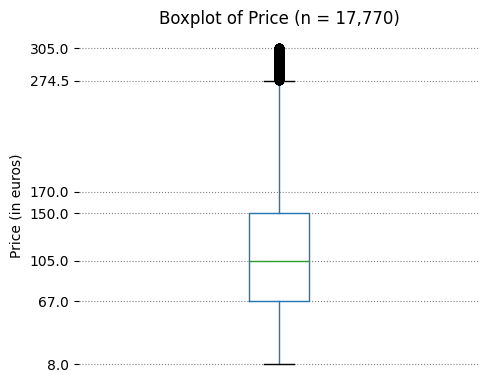

In [ ]:
fig, ax = plt.subplots(figsize = (5, 4))
df_clean.boxplot(column="price", ax = ax)

y_label = [8,67,105,150, 170,274.5, 305]
ax.set_yticks(y_label)
ax.set_frame_on(False)
ax.set_title("Boxplot of Price (n = 17,770)")
ax.set_xlabel("")
ax.set_xticks([])
ax.set_ylabel("Price (in euros)")

plt.grid(True, linestyle = ':', color = 'gray')

plt.tight_layout()

In [ ]:
df_clean.price.describe()

,price
count,17770.000000
mean,114.598537
std,62.299835
min,8.000000
25%,67.000000
50%,105.000000
75%,150.000000
max,305.000000


### **Price** Histogram Insights

Other perspective of the distribution of **price** variable can be gain from histogram. We can observe:

- The mode (most frequent value) was add with a vertical line and it is 90.0 euros
- The values are most concentraded around de mode and get down when get greater, creating an assymetric shape to the graph
- Confirms some of the insights from boxplot

Now, we will check the association with the others variable

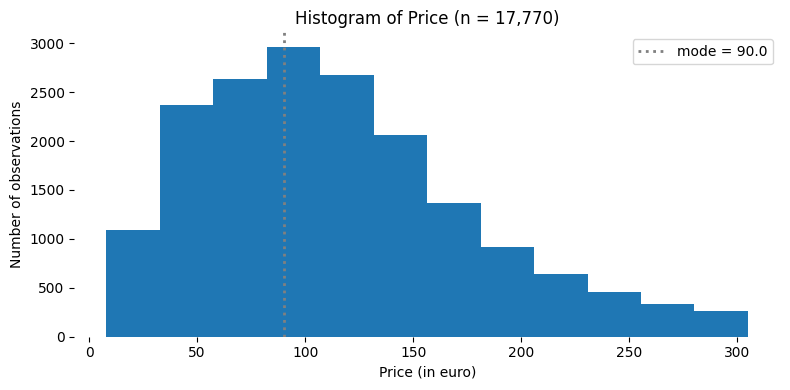

In [ ]:
fig, ax = plt.subplots(figsize = (8,4))
df_clean.hist(column="price", bins=12, grid = 0, ax=ax)
df_clean_mean = df_clean["price"].mean()
df_clean_mode = df_clean["price"].mode().iloc[0]
df_clean_median = df_clean["price"].median()
ax.axvline(x = df_clean_mode , color='gray', linestyle=':', linewidth=2, label = "mode = 90.0")

ax.set_title("Histogram of Price (n = 17,770)")
ax.set_ylabel("Number of observations")
ax.set_xlabel("Price (in euro)")
ax.set_frame_on(False)
ax.legend()
plt.tight_layout()

##Exploring Associations Between **Price** and Other Variables

### **Price** x **Room_type** Boxplot Insights


To understand the association between **price** and the different **room_type**, we can observe the boxplots below:

* The lowest values are ascending in the 'Private room' (8.00 euros), 'Entire home/apt' (9.00 euros), 'Shared room' (15.0 euros) and 'Hotel room' (31.00 euros).
* The lower 75% of the price in 'Shared room" and 'Private room' shows the lowest variation and prices. While 'Entire home/apt' has the greatest variation (a bigger box).
* All categories show an asymmetric box shape ('Entire home/apt', 'Private room', and 'Shared room'), indicating a greater concentration of lower values in the bottom half. The exception is the 'Hotel room' category, which shows a higher concentration of values in the upper part of the box.
* 'Hotel room' show more concentration in vaues between 151 and 170 euros.
* All the variables present outliers, but 'Hotel room' hass less than the othes and 'Private room' has the greatest quantity.

Note the describe below the boxplots to help undestand some values, as the quantity of data in each category.
* 'Entire home/apt' with n = 12,636
* 'Hotel room' with n = 39
* 'Private room' with n = 4,949
* 'Shared room' with n = 146

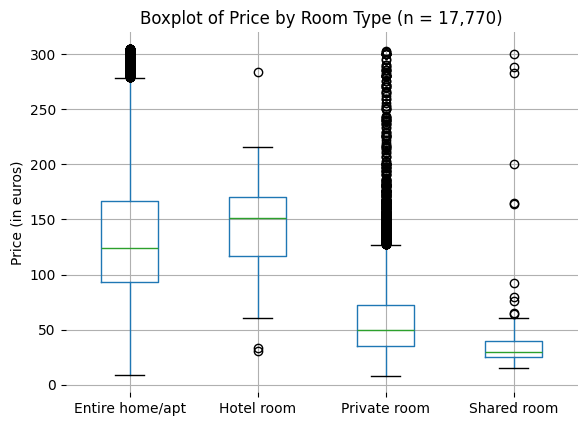

In [ ]:
# room_type
fig, ax = plt.subplots()
df_clean.boxplot(column="price", by="room_type", ax = ax)

ax.set_frame_on(False)
ax.set_title("Boxplot of Price by Room Type (n = 17,770)")
ax.set_ylabel("Price (in euros)")
ax.set_xlabel("")

plt.suptitle("")
plt.show()

In [ ]:
df_clean.groupby("room_type")["price"].describe()

,count,mean,std,min,25%,50%,75%,max
room_type,,,,,,,,
Entire home/apt,12636.0,135.508547,55.872345,9.0,93.0,124.0,167.0,305.0
Hotel room,39.0,141.846154,49.555147,31.0,116.5,151.0,170.0,284.0
Private room,4949.0,63.189331,44.301307,8.0,35.0,50.0,72.0,303.0
Shared room,146.0,40.232877,43.796716,15.0,25.0,29.5,40.0,300.0


### **Price** x **Room_type** Histogram Insights


To understand the association between **price** and the different **room_type** with other representation, we can observe the histograms below:

* It is easier to note the concentration of values and the assymetrical shape of each distributions.

* There are more data for 'Entire home/apt' and 'Priva room', less for 'Shared room' and fewer to 'Hotel room'.




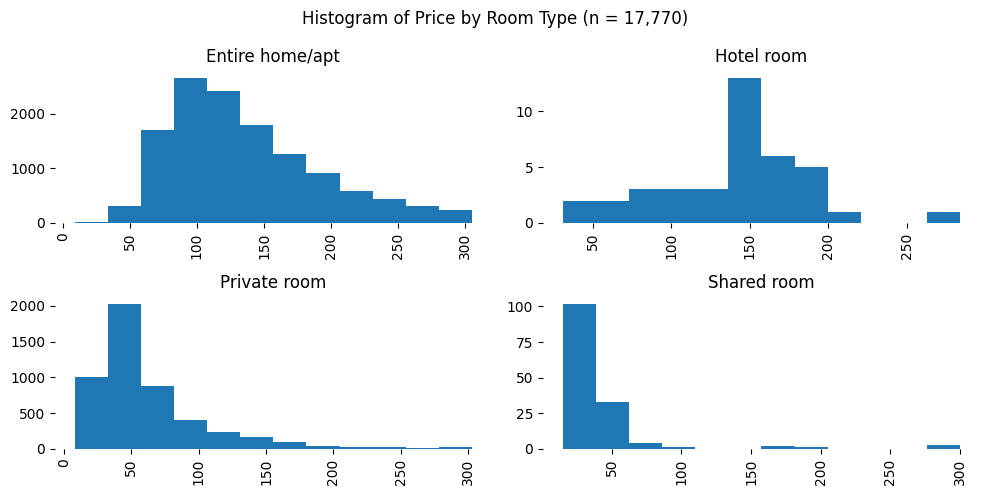

In [ ]:
fig, ax = plt.subplots(nrows = 2, ncols = 2, figsize = (10,5))
df_clean.hist(column="price", by="room_type", bins=12, grid = 0, ax=ax)

plt.suptitle("Histogram of Price by Room Type (n = 17,770)")
ax[0,0].set_frame_on(False)
ax[0,1].set_frame_on(False)
ax[1,0].set_frame_on(False)
ax[1,1].set_frame_on(False)

plt.tight_layout()

### **Room_type** x **Neighbourhood** Heatmap Insights

<img src = "https://www.researchgate.net/publication/384681216/figure/fig2/AS:11431281282221278@1728272507230/Municipality-of-Madrid-divided-into-its-21-districts-Base-map-source-Open-Street-Map.png" width = "75%" />

To understand the quantity of different rooms type on the 21 districts of Madrid the heatmap can be use as below. This graph presents some interest informations:

* There are 'Entire home/apt' and 'Private room' for all the 21 districts.
* There are only 11 districts with 'Shared room' and 5 with 'Hotel room'.
* There are more different of room types in 'Centro'.
* The blank space is a zero quantity

To check the prices, the next heatmap present some interesting informations.




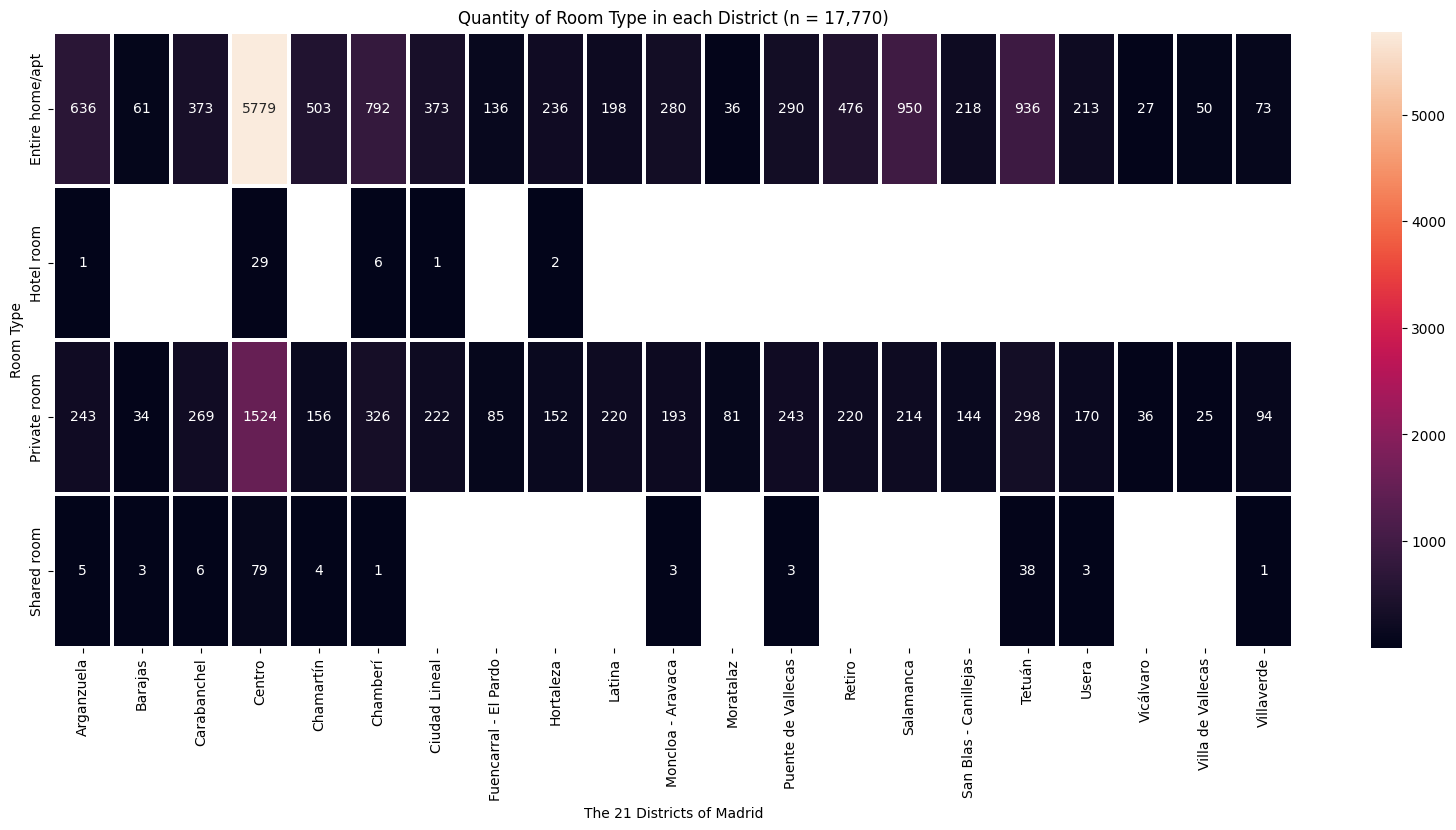

In [ ]:
pivot = df_clean.pivot_table(
    values="price",
    index="room_type",
    columns="neighbourhood_group",
    aggfunc="count"
)

fig, ax = plt.subplots(figsize = (20,8))
sns.heatmap(pivot, annot=True, fmt=".0f", linewidths=1.5, ax=ax)
ax.set_title("Quantity of Room Type in each District (n = 17,770)")
ax.set_xlabel("The 21 Districts of Madrid")
ax.set_ylabel("Room Type")


plt.show()

In [ ]:
df_clean.groupby("neighbourhood_group")["room_type"].value_counts()

neighbourhood_group    room_type      
Arganzuela             Entire home/apt     636
                       Private room        243
                       Shared room           5
                       Hotel room            1
Barajas                Entire home/apt      61
                       Private room         34
                       Shared room           3
Carabanchel            Entire home/apt     373
                       Private room        269
                       Shared room           6
Centro                 Entire home/apt    5779
                       Private room       1524
                       Shared room          79
                       Hotel room           29
Chamartín              Entire home/apt     503
                       Private room        156
                       Shared room           4
Chamberí               Entire home/apt     792
                       Private room        326
                       Hotel room            6
                       Shared room           1
Ciudad Lineal          Entire home/apt     373
                       Private room        222
                       Hotel room            1
Fuencarral - El Pardo  Entire home/apt     136
                       Private room         85
Hortaleza              Entire home/apt     236
                       Private room        152
                       Hotel room            2
Latina                 Private room        220
                       Entire home/apt     198
Moncloa - Aravaca      Entire home/apt     280
                       Private room        193
                       Shared room           3
Moratalaz              Private room         81
                       Entire home/apt      36
Puente de Vallecas     Entire home/apt     290
                       Private room        243
                       Shared room           3
Retiro                 Entire home/apt     476
                       Private room        220
Salamanca              Entire home/apt     950
                       Private room        214
San Blas - Canillejas  Entire home/apt     218
                       Private room        144
Tetuán                 Entire home/apt     936
                       Private room        298
                       Shared room          38
Usera                  Entire home/apt     213
                       Private room        170
                       Shared room           3
Vicálvaro              Private room         36
                       Entire home/apt      27
Villa de Vallecas      Entire home/apt      50
                       Private room         25
Villaverde             Private room         94
                       Entire home/apt      73
                       Shared room           1
Name: count, dtype: int64

### **Price** for **Room_type** x **Neighbourhood** Heatmap Insights


The heatmap of median price of room type in each district was construct to study the **price** of the center value, that is, there are 50% of the values with lowest values and 50% with higest values than the median. Below, we are presenting some insights:

* The highest median are the 'Hotel Room' in 'Centro'.
* The 'Entire home/apt' options has a highest median of 147 and the lowest of 90.
* The 'Shared room', normaly, has the lowest medians, except for 'Chamberí' with a 76 euros listing, with greatest values than some 'Hotel rooms' and all the 'Private room'.


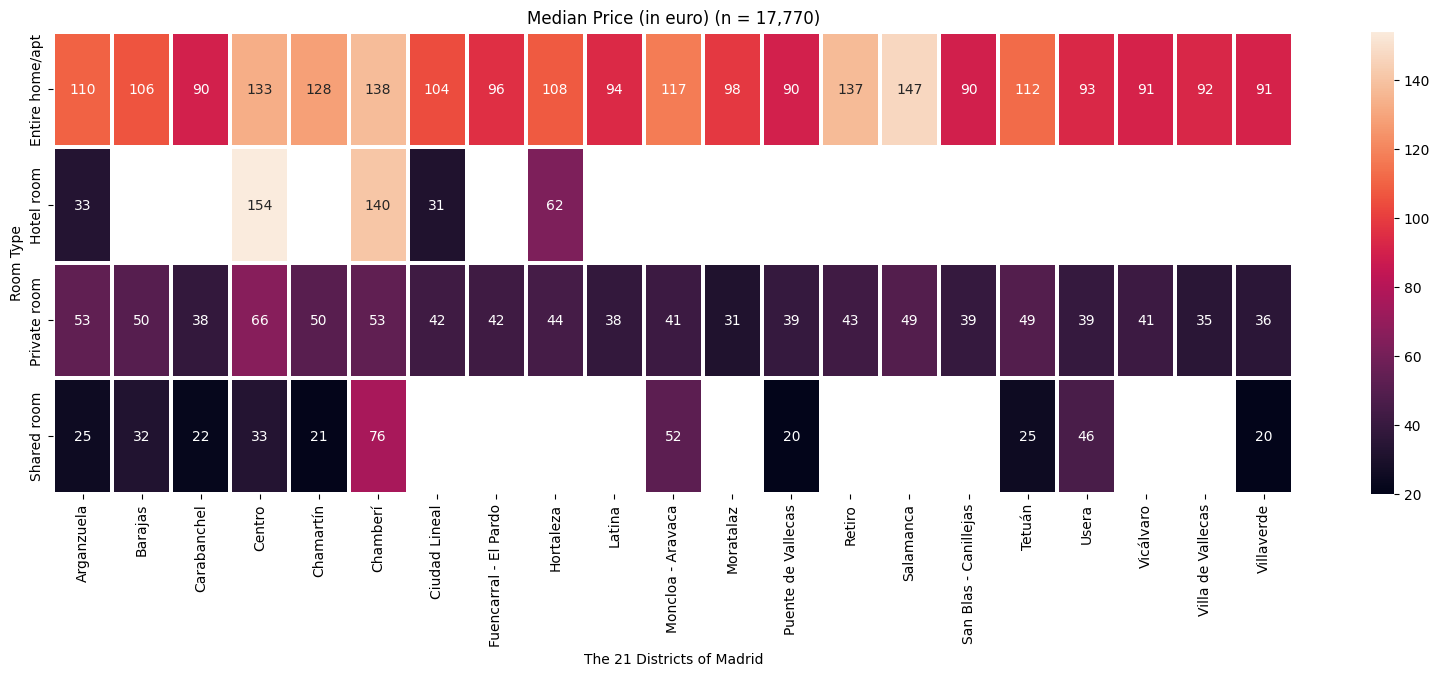

In [ ]:
pivot = df_clean.pivot_table(
    values="price",
    index="room_type",
    columns="neighbourhood_group",
    aggfunc="median"
)

fig, ax = plt.subplots(figsize = (20,6))
sns.heatmap(pivot, annot=True, fmt=".0f", linewidths=1.5, ax=ax)
ax.set_xlabel("The 21 Districts of Madrid")
ax.set_ylabel("Room Type")
ax.set_title("Median Price (in euro) (n = 17,770)")

plt.show()

### **Minimum Nights**

The variable Minimum Nights has a minimum of 1 (day) and a maximum of 600 (days). Because of this possibly outlier, the median has a information more accurate.

The median of Minimum Nights is 2 (days). So, 50% of the listing must be use for, at minimum, 2 days.

The top 10 most frequent values for "minimum_nights" can be check below.


In [ ]:
df_clean["minimum_nights"].describe()

,minimum_nights
count,17770.000000
mean,8.577828
std,19.851204
min,1.000000
25%,1.000000
50%,2.000000
75%,4.000000
max,600.000000


In [ ]:
df_clean["minimum_nights"].value_counts().head(10)

,count
minimum_nights,
1,7720
2,3185
3,1839
30,1242
31,650
4,593
5,433
7,415
28,228


### Correlation of **Price** and **Minimum Nights**

With more than 10,000 values of 1 or 2 days, the scatter plot will be confusing to show specifics results. Therefore, the hexagon plot show more informations, as:

* There are more prices on range 20 to 230 in 1-3 days and 20 to 200 in 28-30 days
* The other days do not show so much information. Because of that, it is possible to use the variable creating in the beginning of this analysis to understand the minimum expect from the listing.

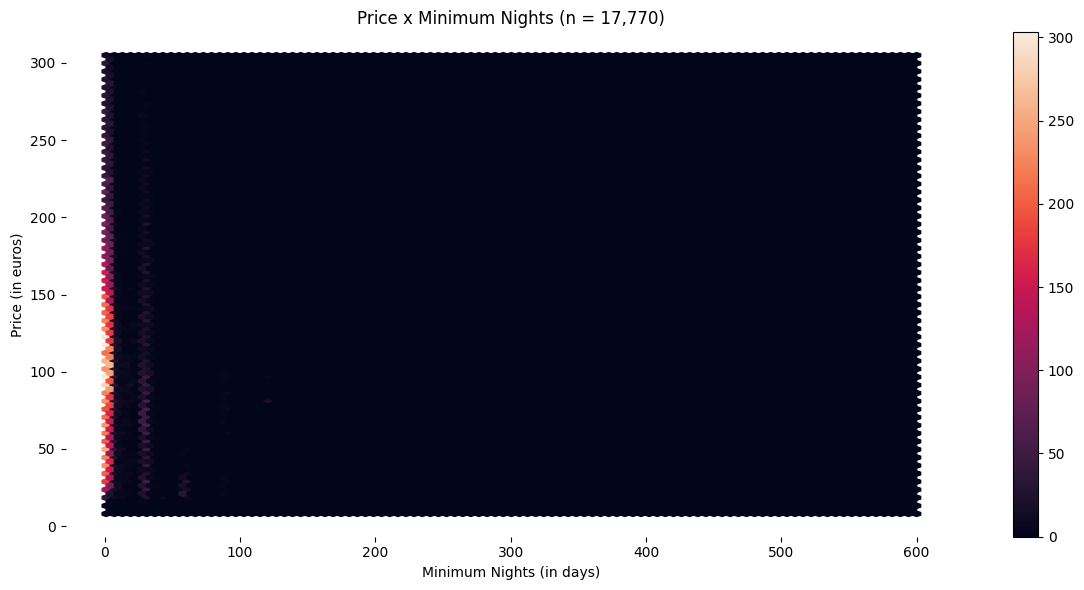

In [ ]:
fig, ax = plt.subplots(figsize = (12,6))
df_clean.plot.hexbin(x = "minimum_nights",
                     y = "price",
                     cmap = "rocket",
                     grid = False,
                     ax = ax)
ax.set_xlabel("Minimum Nights (in days)")
ax.set_ylabel("Price (in euros)")
ax.set_title("Price x Minimum Nights (n = 17,770)")
ax.set_frame_on(False)
plt.tight_layout()

### The **Minimum Total Cost** Statistics Measures Insights

This variabel was created to explore how many the hosts expect to receive from their listing. Some basic measures show that:

* The minimum value expected was 8 euros and the maximum was 69,160 euros.
* The mean is 840.73 euros and the median is 202.00 euros, so the hosts expect receive 202.00 from 50% of their listing.
* There are more hosts expectating 112 to 202 euros in the 50% center values.

The histogram can be show to confirm this informations and bringing other more.


In [ ]:
df_clean["minimum_total_cost"].describe()

,minimum_total_cost
count,17770.000000
mean,840.726674
std,1970.431246
min,8.000000
25%,112.000000
50%,202.000000
75%,539.750000
max,69160.000000


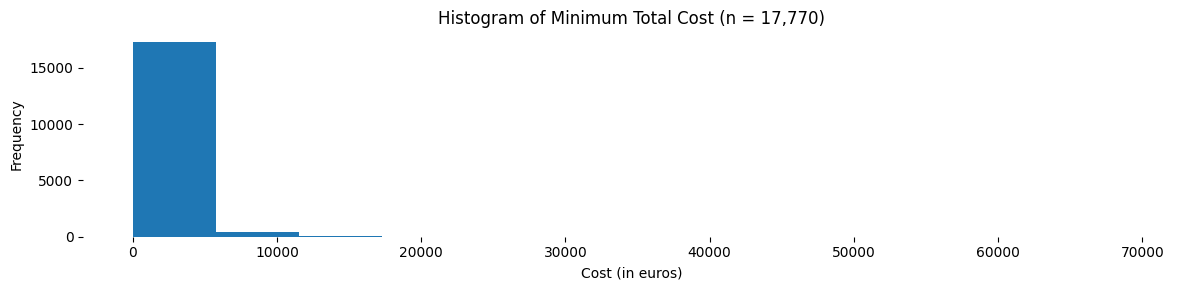

In [ ]:
fig, ax = plt.subplots(figsize = (12,3))
df_clean.hist(column="minimum_total_cost", bins=12, grid = 0, ax=ax)

ax.set_title("Histogram of Minimum Total Cost (n = 17,770)")
ax.set_ylabel("Frequency")
ax.set_xlabel("Cost (in euros)")
ax.set_frame_on(False)
plt.tight_layout()

### The **Minimum Total Cost** boxplots insights

The boxplots has a lot of distortion, because of the extreme values that the **minimum_total_cost** can present. However, there are some insights:


* 'Entire home/apt' has the greatest variability and 'Hotel room' the least.
* There are outliers in all room types
* Because of the concentration, the boxplot of **minimum_total_cost** by 'Hotel room' was created on the right to show the pattern. It is possible to see something similar to the boxplot of price grouped by 'room_type', probabily the quantity of the value of minimum nights are 1.
* On the boxplot for 'Hotel room', the 50% central (the box) has more concentration in values between 150.00 and 170.00 euros

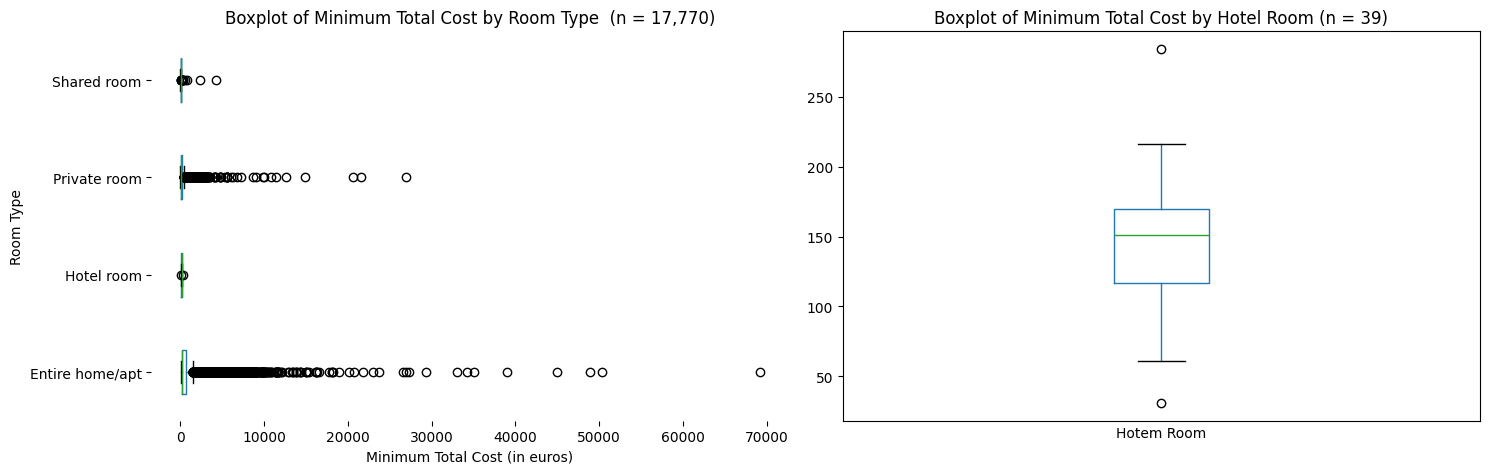

In [ ]:
fig, ax = plt.subplots(figsize = (15,5), nrows = 1, ncols = 2)

df_clean.boxplot(column = "minimum_total_cost",
              vert = False,
              by = "room_type",
              grid = False,
              ax = ax[0]
              )
plt.suptitle("")
ax[0].set_title("Boxplot of Minimum Total Cost by Room Type  (n = 17,770)")
ax[0].set_xlabel("Minimum Total Cost (in euros)")
ax[0].set_ylabel("Room Type")
ax[0].set_frame_on(False)



df_clean.loc[df_clean["room_type"]=="Hotel room"].boxplot(
    column="minimum_total_cost",
    vert = True,
    grid = False,
    label = False,
    ax = ax[1]
    )
ax[1].set_title("")
ax[1].set_title("Boxplot of Minimum Total Cost by Hotel Room (n = 39)")
ax[1].set_xticks([])
ax[1].set_xlabel("Hotem Room")
ax[1].set_ylabel("")



plt.tight_layout()

### **Price** x **Availability**

The **availability_365** can be analyse by its statiscs metrics. It is expect a minimum of 0 (zero) probably the listing was occupied the whole year. However, it is suprising a maximum of 365 days of availability.
The mean (211.9 days) are lower than the median (244.0 days), it indicates lowest values bringind the mean down.
There are more than 50% of the values with more than 244 days of avaibility.

The heaxagon diagram will be used again to understand the relation between Price and Avaibility. We can have some insights:

* There are a region delimited by the price in a range of 50 to 150 euros for almost the whole **avaibility_365**.

* Between 100 and 220 days, the region is stand out less.

* There are a more cases near to 250 and 350 days than the rest of the graph.

This graph shows a heterogeneous graph, with a imprecision in insights. To solve that, a possibility is to create other variable based on **avaibility_365**. This new variable **group_days_30** will create 13 groups of 30 days. From 0 - 30 -> group 1, 31-61 -> group 2, ... .
The groups are heteregoneous, because the first one can have from 0 to 31 days and the last one only have the data from 361, 362, ..., 365. But has a informative proposal.


In [ ]:
df_clean["availability_365"].describe()

,availability_365
count,17770.000000
mean,211.908835
std,115.556720
min,0.000000
25%,96.000000
50%,244.000000
75%,317.000000
max,365.000000


In [ ]:
df_clean[["price", "availability_365"]].corr()

,price,availability_365
price,1.000000,0.011116
availability_365,0.011116,1.000000


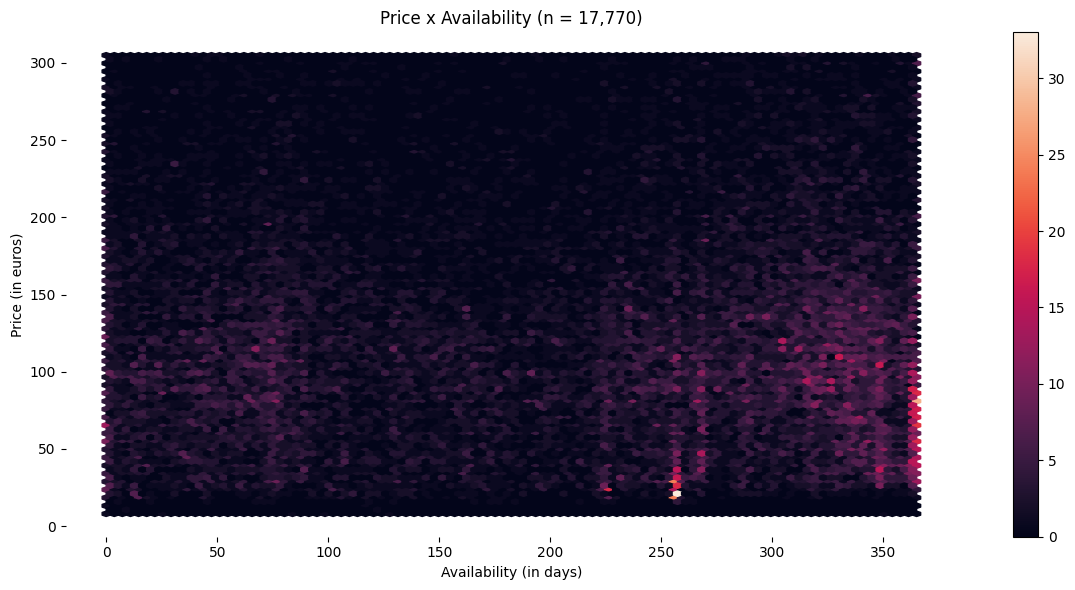

In [ ]:
fig, ax = plt.subplots(figsize = (12,6))
df_clean.plot.hexbin(x = "availability_365",
                     y = "price",
                     cmap = "rocket",
                     grid = False,
                     ax = ax)
ax.set_xlabel("Availability (in days)")
ax.set_ylabel("Price (in euros)")
ax.set_title("Price x Availability (n = 17,770)")
ax.set_frame_on(False)
plt.tight_layout()

In [ ]:
df_clean = df_clean.copy()
df_clean["availability_365"] = df_clean["availability_365"].replace(0,1)
df_clean["group_days_30"] = ((df_clean["availability_365"] - 1) // 30) + 1
df_clean["group_days_30"].sort_values()

,group_days_30
12575,1
12573,1
81,1
75,1
15,1
...,...
24971,13
24980,13
24998,13
18458,13


In [ ]:
df_clean.info()

<class 'pandas.core.frame.DataFrame'>
Index: 17770 entries, 1 to 24999
Data columns (total 8 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   id                   17770 non-null  object 
 1   neighbourhood_group  17770 non-null  object 
 2   room_type            17770 non-null  object 
 3   price                17770 non-null  float64
 4   minimum_nights       17770 non-null  int64  
 5   availability_365     17770 non-null  int64  
 6   minimum_total_cost   17770 non-null  float64
 7   group_days_30        17770 non-null  int64  
dtypes: float64(2), int64(3), object(3)
memory usage: 1.2+ MB


### **Room types** x **Months of Availability**

The heatmap below shows how many listings of each **room_type** are available in each month group.

* 1 month (0 - 30 days) -> group 1

* 2 months (31 - 60 days) -> group 2

* ...

* 12 months (331 - 360 days) -> group 12

* Almost the whole year (361 - 365 days) -> group 13


Some insights:

* There are few ‘Shared room’ and ‘Hotel room’ listings available throughout the year, which is expected since there are only 146 ‘Shared room’ and 39 ‘Hotel room’ listings in total.

* There is a large number of ‘Entire home/apt’ listings available for most of the year. For example, 1,799 listings fall into the group with 301–331 available days.



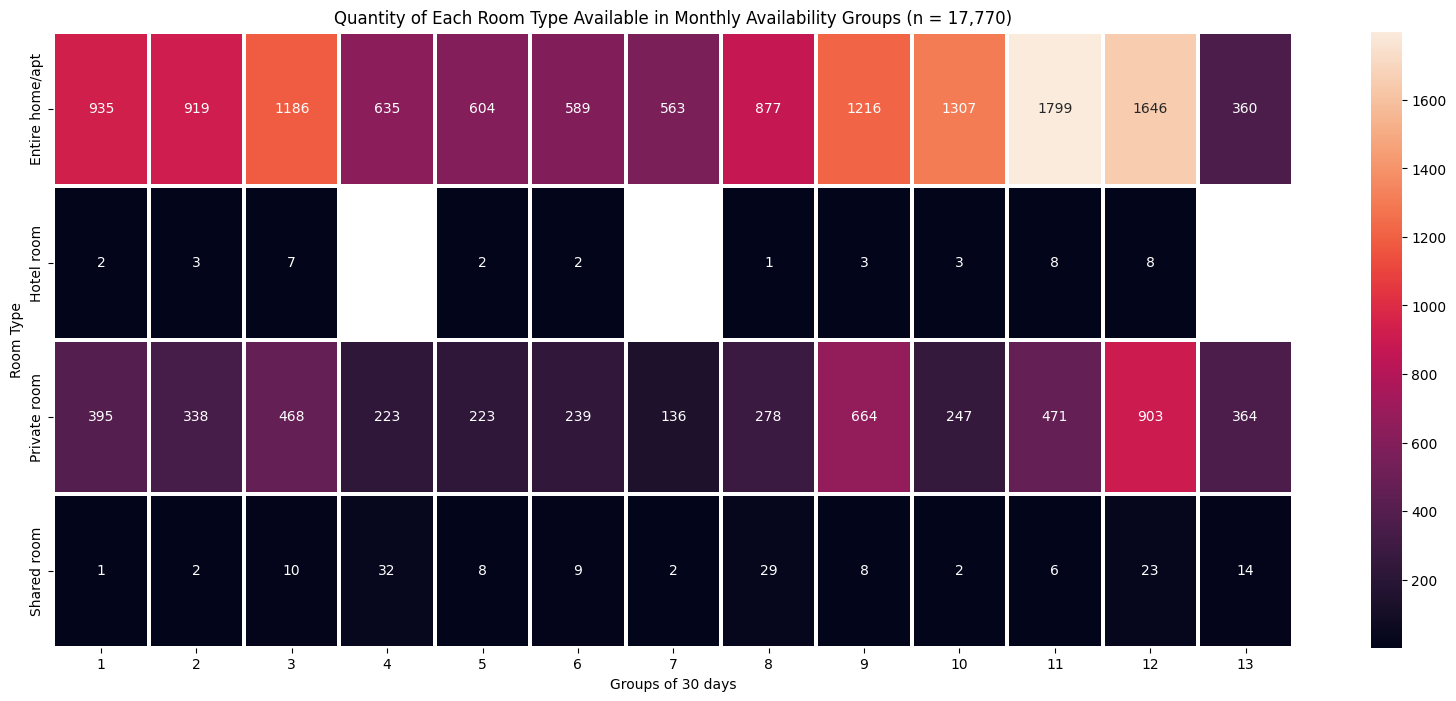

In [ ]:
pivot = df_clean.pivot_table(
    values="price",
    index="room_type",
    columns="group_days_30",
    aggfunc="count"
)

fig, ax = plt.subplots(figsize = (20,8))
sns.heatmap(pivot, annot=True, fmt=".0f", linewidths=1.5, ax=ax)
ax.set_xlabel("Groups of 30 days")
ax.set_ylabel("Room Type")
ax.set_title("Quantity of Each Room Type Available in Monthly Availability Groups (n = 17,770)")

plt.show()

### **Median Price** for **Room Types** x **Months of Availability**

The heatmap below shows the median price for each 'room_type' across the 30-day availability groups.


Some insights:

* The highest median price appears in 'Hotel room' (236.00 euros) in the 150–180 day range (group 6).

* The lowest median price is in 'Shared room', with 20.00 euros in the 120–150 day range (group 5).

* The median price for 'Entire home/apt' stays concentrated between 97.00 and 129.00 euros.

* 'Hotel room' shows more variability, with medians ranging from 31.00 euros in the 210–240 day group (group 8) to 236.00 euros in group 6.




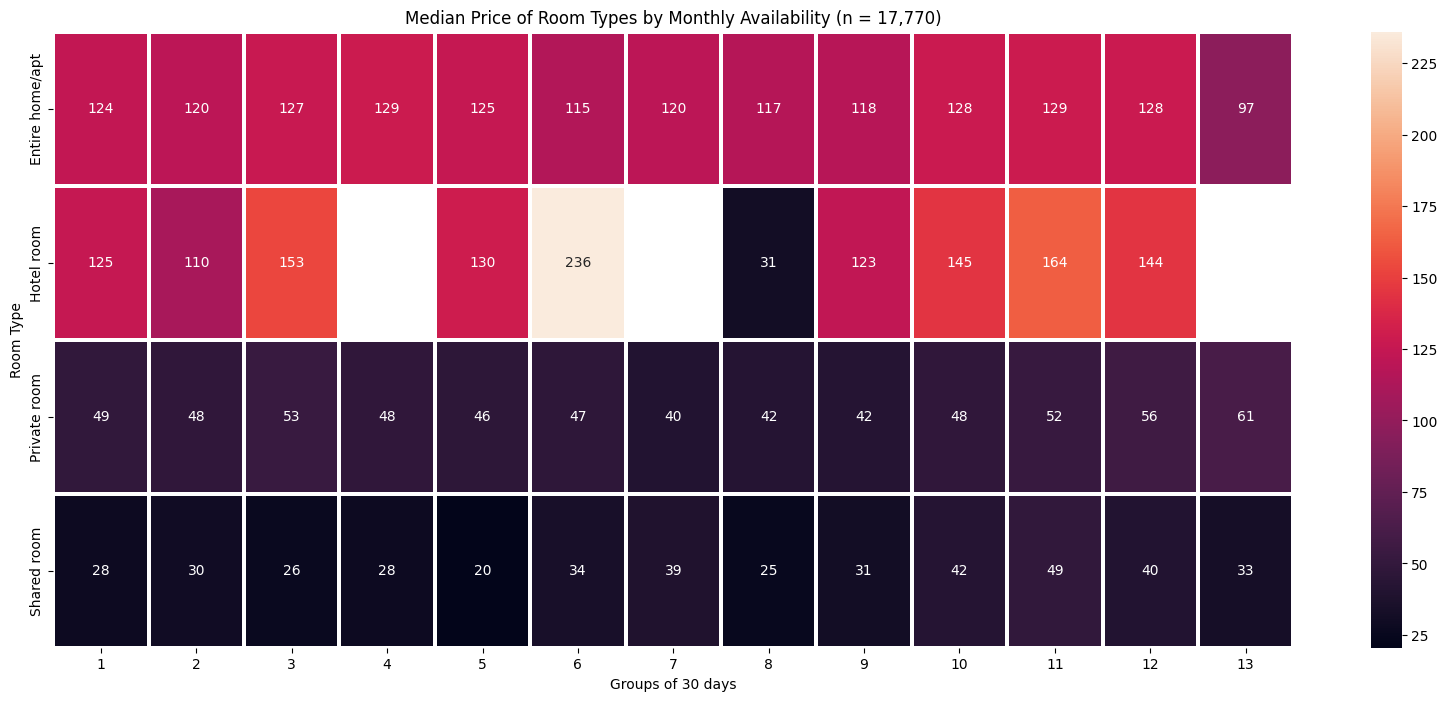

In [ ]:
pivot = df_clean.pivot_table(
    values="price",
    index="room_type",
    columns="group_days_30",
    aggfunc="median"
)

fig, ax = plt.subplots(figsize = (20,8))
sns.heatmap(pivot, annot=True, fmt=".0f", linewidths=1.5, ax=ax)
ax.set_xlabel("Groups of 30 days")
ax.set_ylabel("Room Type")
ax.set_title("Median Price of Room Types by Monthly Availability (n = 17,770)")

plt.show()

## The Outliers

At the beginning of this analysis, the full dataset with 25,000 rows was divided into three parts based on the variable price.

1. The first part is **df_clean**, with 17,770 rows. It has been analyzed since the beginning of this study.
2. The second part contains the rows with null values (6,047 rows). They were dropped at this stage, but in future work they may be studied to explore possible imputation methods.
3. The third part is **df_outliers**, with 1,183 rows where the price values are extremely high. These values distort statistical measures and the visualizations.

After completing the previous analyses, we return to *df_outliers* for additional exploration. The next steps in this analysis will be:

1. Review statistical measures, with special attention to the median due to variability and data concentration in certain regions.
2. Identify where these outlier prices occur and which room types they belong to.
3. Analyze the availability of each room type.


### Outliers: Statistical Measures

There are 1,183 price values in 'df_outliers', with a minimum of 306.00 euros and a maximum of 25,654.00 euros. The mean is 788.97 euros and the median is 431.00 euros. This indicates a concentration of values below 431.00 euros (50% of the data is at or below this point), while higher prices pull the mean upward.

Some plots should be interpreted with caution, because the wide range of values (25,348 euros) can distort the visualization.

Most of the values (75%) are less than or equal to 598.50 euros. We can create groups, as we did with the variable 'availability_365', to study the distribution. One option is to use a strip plot.

In [ ]:
df_outliers["price"].describe()

,price
count,1183.000000
mean,788.974641
std,1843.947109
min,306.000000
25%,354.500000
50%,431.000000
75%,598.500000
max,25654.000000


### Strip Plot of Outlier **Price**

The strip plot shows that most values are below 10,000 euros, with a stronger concentration around prices under 2,000 euros. Therefore, we can create groups of 2,000 euros to continue the outlier analysis.

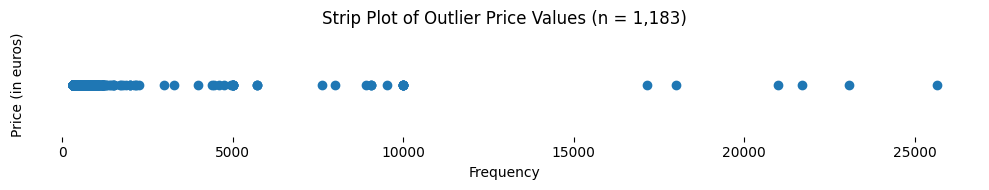

In [ ]:
fig, ax = plt.subplots(figsize = (10,2))
zero_list = [0 for _ in range(len(df_outliers["price"]))]
plt.scatter(x = df_outliers["price"], y = zero_list)
ax.set_title("Strip Plot of Outlier Price Values (n = 1,183)")
ax.set_xlabel("Frequency")
ax.set_ylabel("Price (in euros)")
ax.set_frame_on(False)
ax.set_yticks([])
plt.tight_layout()

In [ ]:
df_outliers = df_outliers.copy()
df_outliers["group_price"] = (df_outliers["price"] // 2000) + 1
df_outliers["group_price"] = df_outliers["group_price"].astype(object)
df_outliers.info()

<class 'pandas.core.frame.DataFrame'>
Index: 1183 entries, 66 to 24975
Data columns (total 8 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   id                   1183 non-null   object 
 1   neighbourhood_group  1183 non-null   object 
 2   room_type            1183 non-null   object 
 3   price                1183 non-null   float64
 4   minimum_nights       1183 non-null   int64  
 5   availability_365     1183 non-null   int64  
 6   minimum_total_cost   1183 non-null   float64
 7   group_price          1183 non-null   object 
dtypes: float64(2), int64(2), object(4)
memory usage: 83.2+ KB


### The top 5 most expensive

The most expensive listings are 'Entire home/apt', with 4 located in 'Centro' and one in 'Puente de Vallecas'.

Among these 5 listings, the highest 'price' is 25,654.00 euros and the lowest is 18,000.00 euros.

In [ ]:
df_outliers.sort_values("price", ascending = False).head()

,id,neighbourhood_group,room_type,price,minimum_nights,availability_365,minimum_total_cost,group_price
579,5361601,Centro,Entire home/apt,25654.0,3,28,76962.0,13.0
8397,53056104,Centro,Entire home/apt,23085.0,5,243,115425.0,12.0
4976,34570478,Centro,Entire home/apt,21685.0,2,137,43370.0,11.0
7174,45249073,Puente de Vallecas,Entire home/apt,21000.0,1,365,21000.0,11.0
13321,942610520665563520,Retiro,Entire home/apt,18000.0,1,365,18000.0,10.0


### **Group Price** x **Room Type** Heatmap Insights

* Prices up to 2,000 euros appear in 974 'Entire home/apt' listings, 163 'Private rooms', 2 'Hotel rooms', and 2 'Shared rooms'.

* The remaining entries in the 'Entire home/apt' category are noticeable because of their large 'price' variation, with some listings costing more than 2,000 euros per day.

* There are 5 'Private rooms' priced above 2,000 euros.

To identify where these listings are located, we can use a heatmap of 'group_price' by 'neighbourhood_group', which shows the count in each category.

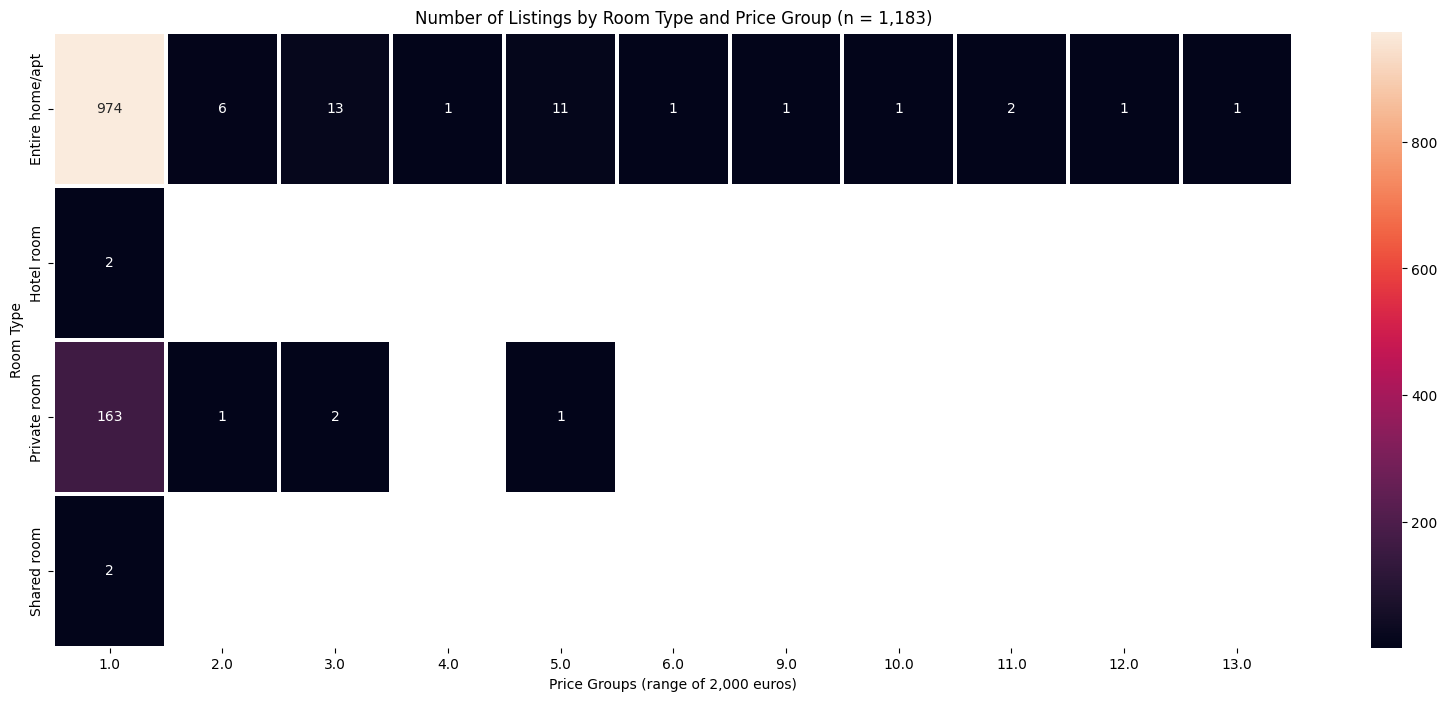

In [ ]:
pivot = df_outliers.pivot_table(
    index="room_type",
    columns="group_price",
    aggfunc="size"
)


fig, ax = plt.subplots(figsize = (20,8))
sns.heatmap(pivot, annot=True, fmt=".0f", linewidths=1.5, ax=ax)
ax.set_xlabel("Price Groups (range of 2,000 euros)")
ax.set_ylabel("Room Type")
ax.set_title("Number of Listings by Room Type and Price Group (n = 1,183)")

plt.show()

### **Group Price** x **Neighbourhood Groups Heatmap Insights** Heatmap Insights

The distribution of outlier listings shows some interesting insights:

* The majority of listings in the outliers dataset are located in 'Centro'.

* There are 136 'Entire home/apt' listings in 'Salamanca' and 66 in 'Chamberí'.

* The two 'Hotel rooms' in 'Centro' are priced at 316.00 and 347.00 euros.

To identify where these listings are located, we use a heatmap of group_price by neighbourhood_group, which shows the count in each category.

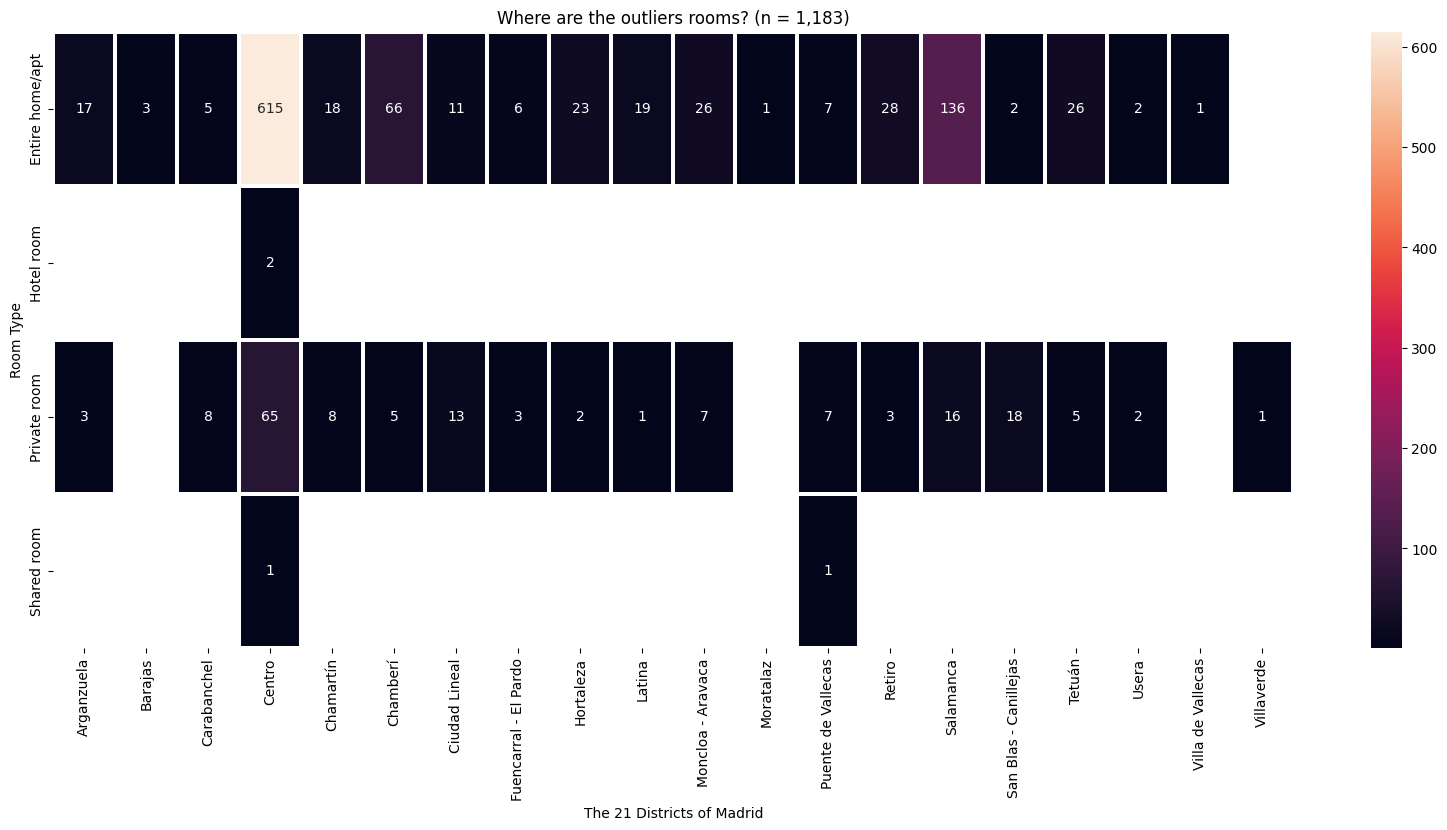

In [ ]:
pivot = df_outliers.pivot_table(
    index="room_type",
    columns="neighbourhood_group",
    aggfunc="size"
)


fig, ax = plt.subplots(figsize = (20,8))
sns.heatmap(pivot, annot=True, fmt=".0f", linewidths=1.5, ax=ax)
ax.set_xlabel("The 21 Districts of Madrid")
ax.set_ylabel("Room Type")
ax.set_title("Where are the outliers rooms? (n = 1,183)")

plt.show()

In [ ]:
df_outliers.loc[df_outliers["room_type"]=="Hotel room"]

,id,neighbourhood_group,room_type,price,minimum_nights,availability_365,minimum_total_cost,group_price
4225,29536072,Centro,Hotel room,347.0,1,178,347.0,1.0
4226,29552407,Centro,Hotel room,316.0,1,164,316.0,1.0


### All the 41 hotels

As mentioned in the introduction, the news focused on hotel room prices. Since the dataset contains only 41 hotel listings, and their prices show less variation compared with other room types, we can analyze all 41:

* The mean is 151.10 euros and the median is 152.00 euros.
* Most of them (31 listings) have a price less than or equal to 170.00 euros per day. However, 10 listings cost more than 170.00 euros and less than 347.00 euros.
* The 5 most frequent prices for hotel rooms are:

  * 3 hotels at 170.00 euros
  * 2 hotels at 82.00 euros.
  * 2 hotels at 153.00 euros.
  * 2 hotels at 145.00 euros.
  * 2 hotels at 130.00 euros.

* The 'price' histogram clearly shows what we discussed: a strong concentration of prices around 170.00 euros, with some cases above 200.00 euros per day.

In [ ]:
df.groupby("room_type")["price"].describe()

,count,mean,std,min,25%,50%,75%,max
room_type,,,,,,,,
Entire home/apt,13648.0,184.980876,564.375520,9.0,96.0,129.0,183.00,25654.0
Hotel room,41.0,151.097561,63.683909,31.0,123.0,152.0,170.00,347.0
Private room,5116.0,84.271892,199.709181,8.0,36.0,50.0,79.00,8900.0
Shared room,148.0,52.864865,116.739879,15.0,25.0,30.0,40.25,1000.0


In [ ]:
df.loc[df["room_type"]=="Hotel room"]["price"].mode()

,price
0,170.0


In [ ]:
df.loc[df["room_type"]=="Hotel room"].groupby(["room_type", "price"])["price"].value_counts().sort_values(ascending = False).head(10)

room_type   price
Hotel room  170.0    3
            82.0     2
            153.0    2
            145.0    2
            130.0    2
            31.0     1
            33.0     1
            61.0     1
            105.0    1
            87.0     1
Name: count, dtype: int64

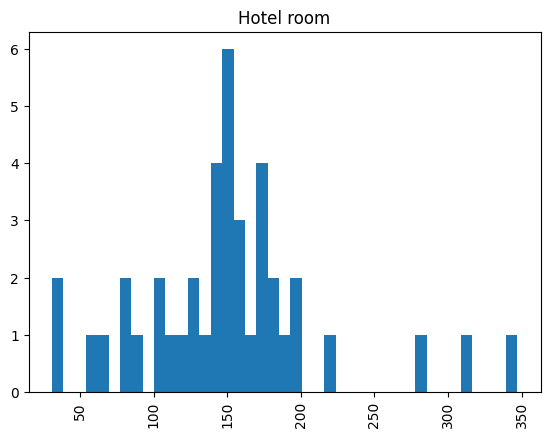

In [ ]:
df.loc[df["room_type"]=="Hotel room"].hist(
    column="price",
    by="room_type",
    bins=41);

# Conclusion

The news in the introduction reported an increase in tourism in Europe and mentioned that hotel prices are reaching higher levels. To explore this topic, a sample of Airbnb listings from Madrid, Comunidad de Madrid, Spain was collected from the Inside Airbnb platform.

The original dataset had 18 variables, but only 6 were used in this analysis. One new variable was also created to support the study. The main goal was to analyse the price variable and understand how it relates to other features through an Exploratory Data Analysis (EDA).

Prices in the dataset vary widely, from 8.00 to 25,654.00 euros per night. Because of this large range, the data were divided into three parts:

1. A reduced dataset (df_clean) with 17,770 rows, containing prices within a reasonable range.

1. An outlier dataset (df_outliers) with 1,183 rows.

1. Rows with null values in price (6,047 rows), which may be explored in future work on data imputation.

Based on df_clean, the main insights are presented below.

## General Insights

### Price
* Prices range from 8.00 to 305.00 euros.
* In the central 50% of the distribution, values are more concentrated between 67.00 and 105.00 euros.
* The most frequent price was 90.00 euros.

### Price x Room Type
* There are 12,636 (71%) Entire home/apt, 4,949 (27%) Private room, 146 (0.8%) Shared room, and 39 (0.2%) Hotel room.
* Even with fewer hotel rooms, prices range from 31.00 to 284.00 euros, with central values around 151.00–170.00 euros.
* Other room types present lower prices overall but show greater variation.

### Price x Districts
The dataset covers listings in the 21 districts of Madrid. Key insights include:

* Centro has the widest variety of room types.
* Hotel rooms appear in only five districts: Arganzuela, Centro, Chamberí, Ciudad Lineal, and Hortaleza.
* The highest median price is from hotel rooms in Centro (154.00 euros). The second highest is Entire home/apt in Salamanca (147.00 euros), followed by hotel rooms in Chamberí (140.00 euros).

### Price x Minimum Nights
* Minimum stay requirements often follow weekly or monthly patterns.
* Price variation is higher for these two periods.

### Price x Availability
* Hotel rooms show lower availability than other room types, even though they present the highest median price for an availability of about six months.

### Outliers
* There are 1,183 outlier rows, with prices ranging from 306.00 to 25,654.00 euros. These include 1,012 (85%) Entire home/apt, 167 (14%) Private room, 2 (0.5%) Hotel room, and 2 (0.5%) Shared room.
* The two hotel rooms in the outlier group cost 316.00 and 347.00 euros.
* The most expensive listings are Entire home/apt.
* Outliers are concentrated mainly in Centro.

## Main Insights
* Hotel rooms show the most frequent price of 170.00 euros (three listings).
* The most expensive hotel in the dataset is in Centro, costing 347.00 euros per day.
* Hotels are fewer than other room types, and their prices are more concentrated, but the highest prices in the dataset come from Entire home/apt listings in Centro, reaching 25,654.00 euros.
* This sample shows that hotel rooms often cost around 170.00 euros or more, but other types of listings can be much more expensive.
* All 21 districts of Madrid offer listings with a wide range of prices.

## Final Insights

Considering the goal of this study, the data supports what the news reported. Most hotel rooms in this sample cost around 170.00 euros per night, and some listings reach higher prices. Although hotel rooms are a small part of the dataset, their median price is higher than many other accommodation types. At the same time, Airbnb also offers options that are much more expensive than hotels, especially entire homes in Centro. This means that the news about higher hotel prices is consistent with the data, but the Airbnb market can be even more variable and sometimes more expensive.

#References:

[1]: "El turismo se traslada masivamente a los apartamentos por los altos precios de los hoteles" (Carlos Molina) <https://encurtador.com.br/vOap>

[2]: "170 euros por habitación y noche: los precios hoteleros no conocen techo" (Carlos Molina) <https://encurtador.com.br/QbRB>

[3]: "Get the Data" (Inside Airbnb) <https://insideairbnb.com/get-the-data/>